In [5]:
# Carlos Salas Alarcón
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt


In [6]:
# Ejercicio 1

# 1. Valores posibles y su probabilidad teórica
x = np.arange(1, 7)
probabilidades = (2 * x - 1) / 36

# 2. Construimos la distribución teórica usando scipy
max_dados = stats.rv_discrete(name='max_dados', values=(x, probabilidades))

# 3. Calculamos la FMP y FDA usando los métodos integrados
fmp = max_dados.pmf(x)
fda = max_dados.cdf(x)

# 4. Creamos y mostramos la tabla
tabla = pd.DataFrame({
    'x (Máximo)': x,
    'P(X=x) - FMP': fmp,
    'F(x) - FDA': fda
})

# Opcional: redondear para mejor visualización
tabla['P(X=x) - FMP'] = tabla['P(X=x) - FMP'].round(4)
tabla['F(x) - FDA'] = tabla['F(x) - FDA'].round(4)

display(tabla)

,x (Máximo),P(X=x) - FMP,F(x) - FDA
0,1,0.0278,0.0278
1,2,0.0833,0.1111
2,3,0.1389,0.2500
3,4,0.1944,0.4444
4,5,0.2500,0.6944
5,6,0.3056,1.0000


In [7]:
# Ejercicio 2

# Asumiendo que 'max_dados' ya está definido del Ejercicio 1
media = max_dados.mean()
varianza = max_dados.var()
desviacion = max_dados.std()

print(f"Media: {media:.4f}")
print(f"Varianza: {varianza:.4f}")
print(f"Desviación típica: {desviacion:.4f}")

Media (Valor esperado): 4.4722
Varianza: 1.9715
Desviación típica: 1.4041


In [9]:
# Ejercicio 3 

from scipy.stats import binom

# Modelamos la tirada de 3 monedas justas
monedas = binom(n=3, p=0.5)

# Calculamos el valor esperado E[X]
esperanza = (100 * monedas.pmf(3)) + (25 * monedas.pmf(2)) + (0 * monedas.cdf(1))

print(f"Precio justo de la apuesta: {esperanza:.3f} €")

Precio justo de la apuesta: 21.875 €


In [10]:
# Ejercicio 4

from scipy.stats import binom

n = 6
p = 0.5
hijos = binom(n, p)

# a) Todos varones: P(X = 6)
p_todos = hijos.pmf(6)

# b) Al menos dos varones: P(X >= 2) = 1 - P(X <= 1)
# sf (survival function) es equivalente a 1 - cdf
p_al_menos_dos = hijos.sf(1) 

# c) Tres varones: P(X = 3)
p_tres = hijos.pmf(3)

# d) Media y desviación típica
media = hijos.mean()
desviacion = hijos.std()

print(f"a) Todos varones: {p_todos:.4f}")
print(f"b) Al menos 2 varones: {p_al_menos_dos:.4f}")
print(f"c) Tres varones: {p_tres:.4f}")
print(f"d) Media: {media:.4f}, Desviación típica: {desviacion:.4f}")

a) Todos varones: 0.0156
b) Al menos 2 varones: 0.8906
c) Tres varones: 0.3125
d) Media: 3.0000, Desviación típica: 1.2247


In [11]:
# Ejercicio 5

from scipy.stats import binom

# Definimos la variable aleatoria
test = binom(n=10, p=0.25)

# a) Exactamente cuatro: P(X = 4)
p_cuatro = test.pmf(4)

# b) Ninguna: P(X = 0)
p_cero = test.pmf(0)

# c) Al menos 1: P(X >= 1) = 1 - P(X = 0)
p_al_menos_uno = test.sf(0)

# d) Más de 3: P(X > 3) = P(X >= 4)
p_mas_de_tres = test.sf(3)

# e) Solo 2: P(X = 2)
p_dos = test.pmf(2)

print(f"a) Exactamente 4: {p_cuatro:.4f}")
print(f"b) Ninguna: {p_cero:.4f}")
print(f"c) Al menos 1: {p_al_menos_uno:.4f}")
print(f"d) Más de 3: {p_mas_de_tres:.4f}")
print(f"e) Solo 2: {p_dos:.4f}")

a) Exactamente 4: 0.1460
b) Ninguna: 0.0563
c) Al menos 1: 0.9437
d) Más de 3: 0.2241
e) Solo 2: 0.2816


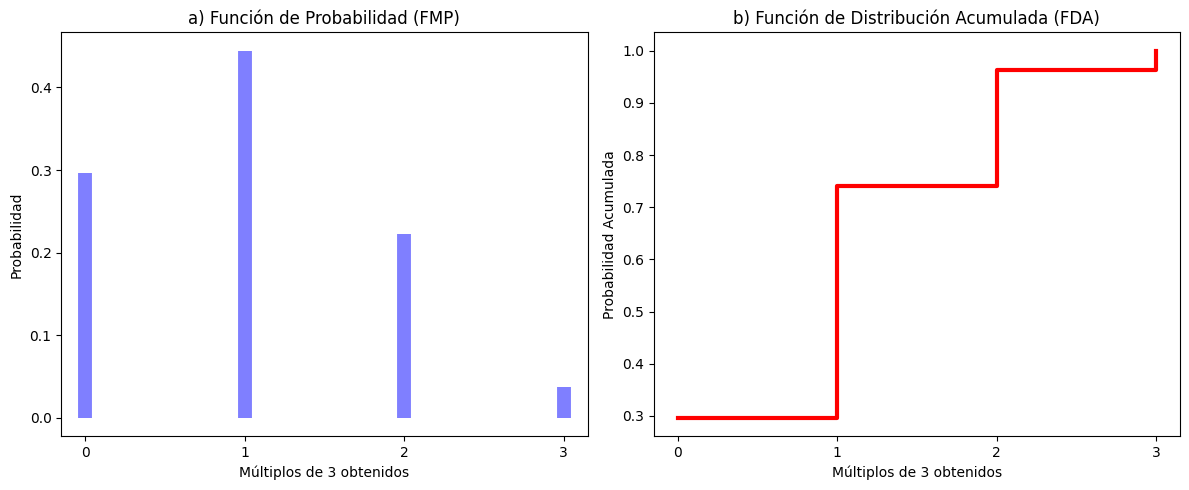

Probabilidades FMP: [0.2963 0.4444 0.2222 0.037 ]
Probabilidades FDA: [0.2963 0.7407 0.963  1.    ]
c) Media: 1.0000, Desviación típica: 0.8165


In [13]:
# Ejercicio 6

# Parámetros de la binomial
n = 3
p = 1/3
dados = binom(n, p)
x = np.arange(0, 4)

# a) Función de probabilidad
fmp = dados.pmf(x)

# b) Función de distribución
fda = dados.cdf(x)

# Gráficas
plt.figure(figsize=(12, 5))

# Gráfica a) FMP
plt.subplot(1, 2, 1)
plt.vlines(x, 0, fmp, colors='b', lw=10, alpha=0.5)
plt.title('a) Función de Probabilidad (FMP)')
plt.xlabel('Múltiplos de 3 obtenidos')
plt.ylabel('Probabilidad')
plt.xticks(x)

# Gráfica b) FDA
plt.subplot(1, 2, 2)
plt.step(x, fda, where='post', color='r', lw=3)
plt.title('b) Función de Distribución Acumulada (FDA)')
plt.xlabel('Múltiplos de 3 obtenidos')
plt.ylabel('Probabilidad Acumulada')
plt.xticks(x)

plt.tight_layout()
plt.show()

# c) Media y desviación típica
media = dados.mean()
desviacion = dados.std()

print(f"Probabilidades FMP: {np.round(fmp, 4)}")
print(f"Probabilidades FDA: {np.round(fda, 4)}")
print(f"Media: {media:.4f}, Desviación típica: {desviacion:.4f}")

In [14]:
# Ejercicio 7

n = 10
p = 0.3
concurso = binom(n, p)

# a) Más de 8 personas: P(X > 8)
p_mas_ocho = concurso.sf(8)

# b) Algunas de las diez personas (al menos 1): P(X > 0)
p_algunas = concurso.sf(0)

# c) Media y desviación típica
media = concurso.mean()
desviacion = concurso.std()

print(f"a) Más de 8 personas: {p_mas_ocho:.4f}")
print(f"b) Algunas de las diez personas: {p_algunas:.4f}")
print(f"c) Media: {media:.4f}, Desviación típica: {desviacion:.4f}")

a) Más de 8 personas: 0.0001
b) Algunas de las diez personas: 0.9718
c) Media: 3.0000, Desviación típica: 1.4491


b) Exactamente 4 clientes: 0.1339
c) Al menos 6 clientes: 0.5543
d) Entre 6 y 8 clientes: 0.4016

e) Muestra de 10 días: [6 6 4 5 4 6 4 4 9 3]


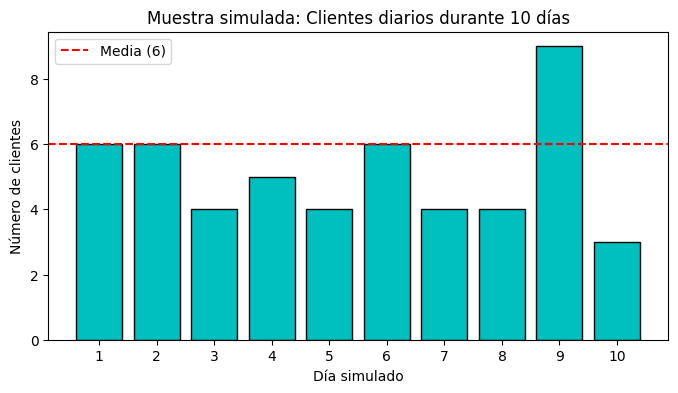

In [16]:
# Ejercicio 8

from scipy.stats import poisson

# Definimos la distribución de Poisson con lambda = 6
mu = 6
sucursal = poisson(mu)

# b) Exactamente 4 clientes: P(X = 4)
p_cuatro = sucursal.pmf(4)

# c) Al menos 6 clientes: P(X >= 6) = 1 - P(X <= 5)
p_al_menos_seis = sucursal.sf(5)

# d) Entre 6 y 8 (incluidos): P(6 <= X <= 8) = F(8) - F(5)
p_entre_6_y_8 = sucursal.cdf(8) - sucursal.cdf(5)

print(f"b) Exactamente 4 clientes: {p_cuatro:.4f}")
print(f"c) Al menos 6 clientes: {p_al_menos_seis:.4f}")
print(f"d) Entre 6 y 8 clientes: {p_entre_6_y_8:.4f}")

# e) Generar muestra de 10 valores aleatorios
np.random.seed(42) # Semilla opcional para reproducibilidad
muestra = sucursal.rvs(size=10)
print(f"\ne) Muestra de 10 días: {muestra}")

# Representación de la muestra
plt.figure(figsize=(8, 4))
plt.bar(range(1, 11), muestra, color='c', edgecolor='black')
plt.axhline(mu, color='r', linestyle='--', label='Media (6)')
plt.title('Muestra simulada: Clientes diarios durante 10 días')
plt.xlabel('Día simulado')
plt.ylabel('Número de clientes')
plt.xticks(range(1, 11))
plt.legend()
plt.show()

In [17]:
# Ejercicio 9

from scipy.stats import norm

# Definimos la distribución Normal N(70, 3)
mu = 70
sigma = 3
pesos = norm(loc=mu, scale=sigma)

# a) Entre 60 y 75 kg
p_60_75 = pesos.cdf(75) - pesos.cdf(60)

# b) Más de 62 kg
p_mas_62 = pesos.sf(62)

# c) Exactamente 64 kg (En una variable continua, la probabilidad de un punto exacto es 0)
p_64 = 0 

# d) Peso mínimo del 10% más pesado (Percentil 90)
peso_min_10 = pesos.ppf(0.90)

# e) Doce pesos aleatorios
np.random.seed(42) # Opcional para reproducibilidad
muestra_12 = pesos.rvs(size=12)

print(f"a) Entre 60 y 75 kg: {p_60_75:.4f}")
print(f"b) Más de 62 kg: {p_mas_62:.4f}")
print(f"c) Exactamente 64 kg: {p_64}")
print(f"d) Mínimo del 10% más pesado: {peso_min_10:.2f} kg")
print(f"e) Muestra de 12 pesos:\n{np.round(muestra_12, 2)}")

a) Entre 60 y 75 kg: 0.9518
b) Más de 62 kg: 0.9962
c) Exactamente 64 kg: 0
d) Mínimo del 10% más pesado: 73.84 kg
e) Muestra de 12 pesos:
[71.49 69.59 71.94 74.57 69.3  69.3  74.74 72.3  68.59 71.63 68.61 68.6 ]


In [18]:
# Ejercicio 10

# Definimos la distribución Normal N(106, 8)
mu = 106
sigma = 8
glucosa = norm(loc=mu, scale=sigma)

# a) Inferior a 120 mg/ml: P(X < 120)
p_inf_120 = glucosa.cdf(120)

# b) Porcentaje entre 90 y 130 mg/ml
p_90_130 = glucosa.cdf(130) - glucosa.cdf(90)
porcentaje = p_90_130 * 100

# c) Valor que deja por debajo al 25% (Percentil 25)
valor_25 = glucosa.ppf(0.25)

# d) Muestra de tamaño 12 con N(5, 5)
np.random.seed(42) # Semilla opcional
muestra_d = norm(loc=5, scale=5).rvs(size=12)

print(f"a) Inferior a 120 mg/ml: {p_inf_120:.4f}")
print(f"b) Porcentaje entre 90 y 130 mg/ml: {porcentaje:.2f}%")
print(f"c) Valor para el 25% inferior: {valor_25:.2f} mg/ml")
print(f"d) Muestra N(5, 5):\n{np.round(muestra_d, 2)}")

a) Inferior a 120 mg/ml: 0.9599
b) Porcentaje entre 90 y 130 mg/ml: 97.59%
c) Valor para el 25% inferior: 100.60 mg/ml
d) Muestra N(5, 5):
[ 7.48  4.31  8.24 12.62  3.83  3.83 12.9   8.84  2.65  7.71  2.68  2.67]


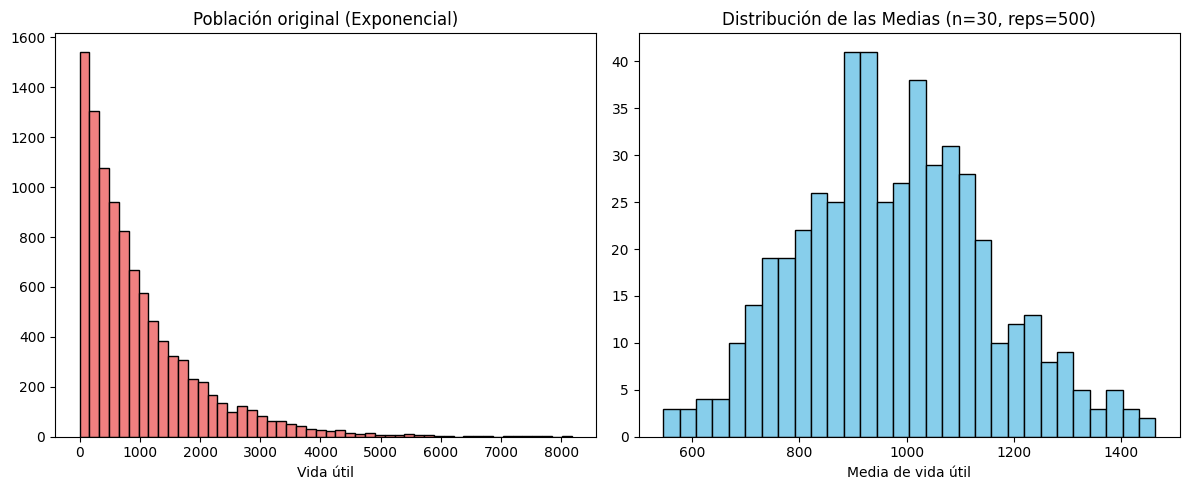

In [20]:
# Ejercicio 11

# 1. Población inicial con distribución exponencial
np.random.seed(42) # Semilla opcional
poblacion = np.random.exponential(scale=1000, size=10000)

# 2. Simulación: extraer lotes de 30 bombillas, 500 veces
n_lote = 30
repeticiones = 500
medias_muestrales = [np.mean(np.random.choice(poblacion, size=n_lote)) for _ in range(repeticiones)]

# 3. Representación gráfica para comparar
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de la población (Exponencial)
ax1.hist(poblacion, bins=50, color='lightcoral', edgecolor='black')
ax1.set_title('Población original (Exponencial)')
ax1.set_xlabel('Vida útil')

# Gráfico de las medias muestrales (Normal)
ax2.hist(medias_muestrales, bins=30, color='skyblue', edgecolor='black')
ax2.set_title(f'Distribución de las Medias (n={n_lote}, reps={repeticiones})')
ax2.set_xlabel('Media de vida útil')

plt.tight_layout()
plt.show()

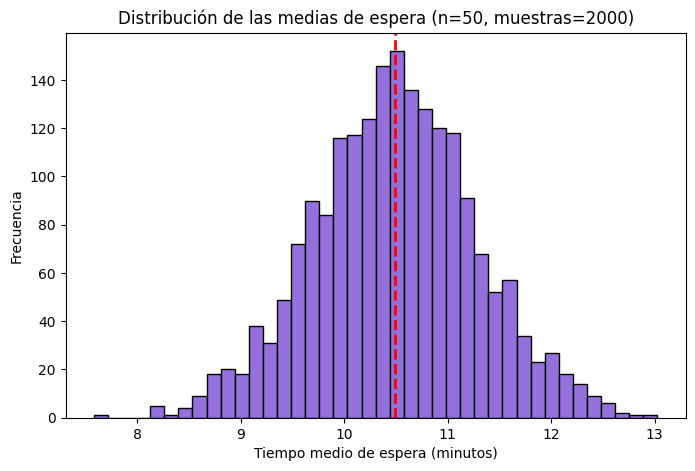

El tiempo medio de espera en el pico es aproximadamente: 10.49 minutos


In [26]:
# Ejercicio 12

from scipy.stats import uniform

# Parámetros
n_clientes = 50
n_samples = 2000

# Definimos la uniforme con scipy: loc=inicio, scale=ancho (20-1=19)
dist_espera = uniform(loc=1, scale=19)

# Simulación empírica de las 2000 medias
np.random.seed(0)
medias = [np.mean(dist_espera.rvs(size=n_clientes)) for _ in range(n_samples)]

# Gráfica
plt.figure(figsize=(8, 5))
plt.hist(medias, bins=40, color='mediumpurple', edgecolor='black')
plt.title('Distribución de las medias de espera (n=50, muestras=2000)')
plt.xlabel('Tiempo medio de espera (minutos)')
plt.ylabel('Frecuencia')
plt.axvline(np.mean(medias), color='red', linestyle='dashed', linewidth=2)
plt.show()

print(f"El tiempo medio de espera en el pico es aproximadamente: {np.mean(medias):.2f} minutos")

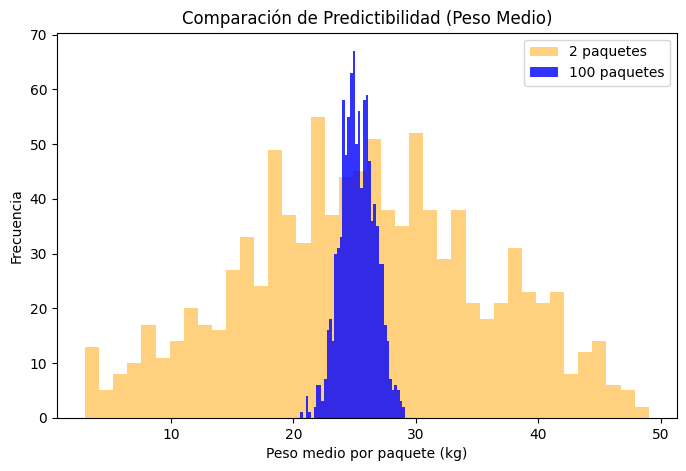

In [27]:
# Ejercicio 13

# 1. Población inicial
np.random.seed(42)
x = np.random.randint(low=1, high=50, size=5000)

# 2. Simulaciones (1000 viajes para cada caso)
viajes = 1000
camion_2 = [np.mean(np.random.choice(x, size=2)) for _ in range(viajes)]
camion_100 = [np.mean(np.random.choice(x, size=100)) for _ in range(viajes)]

# 3. Gráfica comparativa
plt.figure(figsize=(8, 5))
plt.hist(camion_2, bins=40, alpha=0.5, label='2 paquetes', color='orange')
plt.hist(camion_100, bins=40, alpha=0.8, label='100 paquetes', color='blue')

plt.title('Comparación de Predictibilidad (Peso Medio)')
plt.xlabel('Peso medio por paquete (kg)')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

In [183]:
# Ejercicio 14

# 1. Población inicial (Gasto de clientes - Distribución Pareto)
np.random.seed(42) # Semilla opcional
x = np.random.pareto(a=2, size=10000) * 50

# 2. Configuración de la simulación
sample_sizes = [10, 100, 1000]
repeticiones = 1000

plt.figure(figsize=(15, 5))

# 3. Bucle para probar cada tamaño de muestra
for i, n in enumerate(sample_sizes):
    # Extraemos 'n' datos al azar y calculamos su media, repetido 1000 veces
    medias = [np.mean(np.random.choice(x, size=n)) for _ in range(repeticiones)]
    
    # Dibujamos el histograma
    plt.subplot(1, 3, i+1)
    plt.hist(medias, bins=40, color='seagreen', edgecolor='black', alpha=0.7)
    plt.title(f'Tamaño de muestra (n) = {n}')
    plt.xlabel('Gasto medio')

plt.tight_layout()
plt.show()